In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from sklearn import datasets 
from sklearn.decomposition import PCA

In [ ]:
# In this project, we can compare accuracy models trained on raw data and PCA transformed data of same data
# We are using the MNIST handwritten digits dataset from sklearn for this project

In [22]:
X, y = datasets.fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True)


In [23]:
type(X)

pandas.core.frame.DataFrame

In [24]:
X.shape

(70000, 784)

In [25]:
y.shape

(70000,)

In [26]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Let check if the values are actually real number 
# the information we have below shows that values are actually small decimals because the original values where normalized by 225 
# oringal value is between 0-255

X.iloc[0:10,0:10].describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
count,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


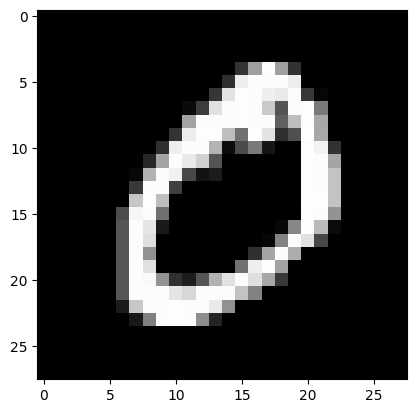

In [27]:
X_np = X.to_numpy()
single_image_np = X_np[1,:].reshape(28,28)
plt.imshow(single_image_np, cmap="gray")

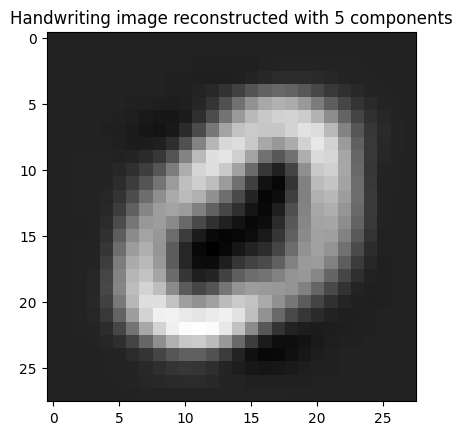

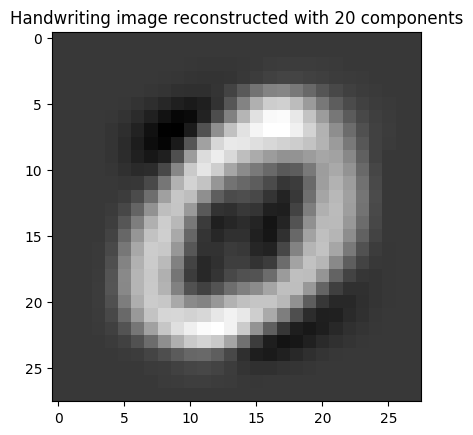

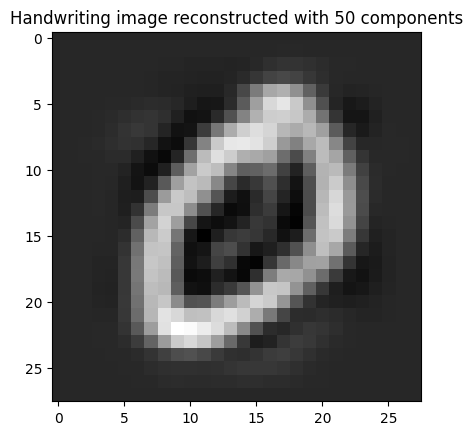

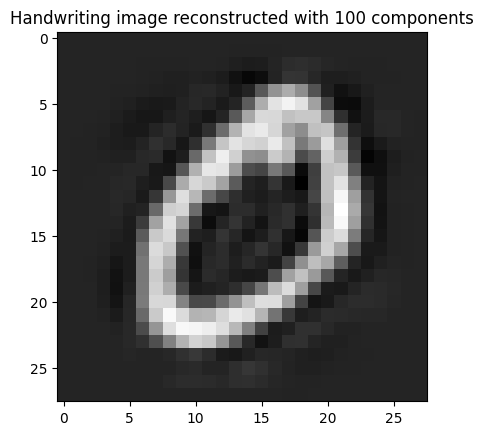

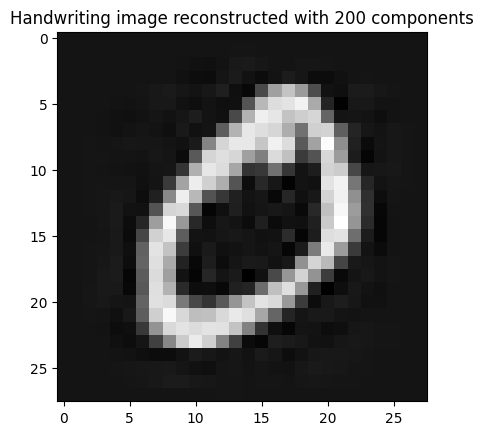

Text(0.5, 1.0, 'handwriting image origial dimensionality')

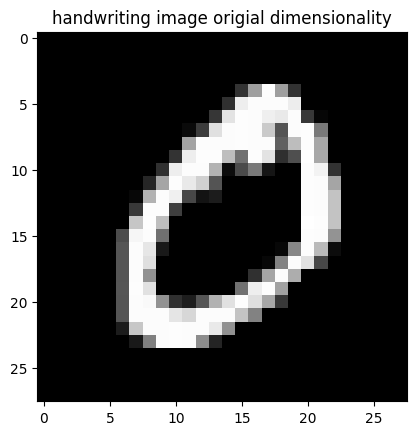

In [ ]:
# dimentinality reduction using 5, 20, 50, 100 components
# Define number of components for PCA
data = X_np
number_of_components = [5, 20, 50, 100, 200]

# Perform PCA and visualize reconstructed images
for n in number_of_components:
  pca = PCA(n_components=n)
  data_pca = pca.fit_transform(data)
  # Inverse transform to reconstruct the images
  datas_inverse = pca.inverse_transform(data_pca)
        
  # visualize reconstructed image after dimensionality reduction, index= 1
  handwriting_image_reconstructed = datas_inverse[1].reshape(28, 28)
  plt.imshow(handwriting_image_reconstructed, cmap="gray")
  plt.title(f"Handwriting image reconstructed with {n} components")
  plt.show()

# visualize one original image from the dataset, index=1
plt.imshow(single_image_np, cmap="gray")
plt.title(f"handwriting image origial dimensionality")

In [17]:
# let join the target to the X dataframe for easier handling and store in our input folder as train.csv
X['target'] = y


In [18]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [20]:
X.to_csv('../input/train_mnist.csv', index=False)